# LDA (Latent Dirichlet Allocation)

In [2]:
from pathlib import Path
import sys
import ast
import itertools
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from gensim import corpora, models
from gensim.models import CoherenceModel

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for p in (OUTPUT_DIR, MODELS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(SRC_DIR))

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis


## 1. Загрузка предобработанных данных

In [3]:
df = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
df["tokens"] = df["tokens"].apply(lambda x: x.split() if isinstance(x, str) else x)

dictionary = corpora.Dictionary.load(str(MODELS_DIR / "gensim_dictionary.dict"))
corpus = list(corpora.MmCorpus(str(MODELS_DIR / "gensim_corpus.mm")))
texts = df["tokens"].tolist()

print(f"Документов: {len(df)}")
print(f"Размер словаря: {len(dictionary)}")
print(f"Размер корпуса: {len(corpus)}")

Документов: 6385
Размер словаря: 10000
Размер корпуса: 6385


## 2. Подбор гиперпараметров (grid search по когерентности)

In [4]:
# Диапазоны параметров
num_topics_range = [5, 10, 15, 20, 25, 30]
alpha_range = ["asymmetric", "auto"]
eta_range = ["auto", None]
passes_range = [10, 20, 30]
chunksize = 2000
iterations = 400

param_combinations = list(itertools.product(
    num_topics_range, alpha_range, eta_range, passes_range
))
print(f"Всего комбинаций: {len(param_combinations)}")

Всего комбинаций: 72


In [5]:
lda_results = []

for num_topics, alpha, eta, passes in tqdm(param_combinations, desc="LDA grid search"):
    try:
        model = models.LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=passes,
            iterations=iterations,
            chunksize=chunksize,
            alpha=alpha,
            eta=eta,
            workers=4,
            random_state=42,
        )

        coherence = CoherenceModel(
            model=model, texts=texts, dictionary=dictionary, coherence="c_v"
        ).get_coherence()

        perplexity = model.log_perplexity(corpus)

        lda_results.append({
            "num_topics": num_topics,
            "alpha": alpha,
            "eta": eta if eta is not None else "None",
            "passes": passes,
            "coherence": coherence,
            "perplexity": perplexity,
        })

    except Exception as e:
        print(f"Ошибка [{num_topics}, {alpha}, {eta}, {passes}]: {e}")

lda_results_df = (
    pd.DataFrame(lda_results)
    .sort_values("coherence", ascending=False)
    .reset_index(drop=True)
)
lda_results_df.to_csv(OUTPUT_DIR / "lda_optimization_results.csv", index=False)

print("\nТоп-10 конфигураций LDA:")
print(lda_results_df.head(10).to_string(index=False))

LDA grid search:   8%|▊         | 6/72 [07:22<1:26:15, 78.41s/it]

Ошибка [5, auto, auto, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [5, auto, auto, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [5, auto, auto, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [5, auto, None, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [5, auto, None, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [5, auto, None, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.


LDA grid search:  25%|██▌       | 18/72 [14:38<52:49, 58.70s/it] 

Ошибка [10, auto, auto, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [10, auto, auto, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [10, auto, auto, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [10, auto, None, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [10, auto, None, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [10, auto, None, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.


LDA grid search:  42%|████▏     | 30/72 [22:17<41:48, 59.74s/it]

...

Ошибка [20, auto, auto, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [20, auto, auto, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [20, auto, auto, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [20, auto, None, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [20, auto, None, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [20, auto, None, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.


LDA grid search:  75%|███████▌  | 54/72 [38:02<19:04, 63.60s/it]

Ошибка [25, auto, auto, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [25, auto, auto, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [25, auto, auto, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [25, auto, None, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [25, auto, None, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [25, auto, None, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.


LDA grid search: 100%|██████████| 72/72 [46:26<00:00, 38.70s/it]

Ошибка [30, auto, auto, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [30, auto, auto, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [30, auto, auto, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [30, auto, None, 10]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [30, auto, None, 20]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.
Ошибка [30, auto, None, 30]: auto-tuning alpha not implemented in LdaMulticore; use plain LdaModel.

Топ-10 конфигураций LDA:
 num_topics      alpha  eta  passes  coherence  perplexity
         25 asymmetric auto      30   0.551433   -7.023981
         25 asymmetric None      30   0.551433   -7.037318
         30 asymmetric auto      30   0.534394   -7.014800
         30 asymmetric None      30   0.534394   -7.028624
         25 asymmetric auto      20   0.532831   -7.035369
         25 asymmetr

## 3. Визуализация результатов оптимизации

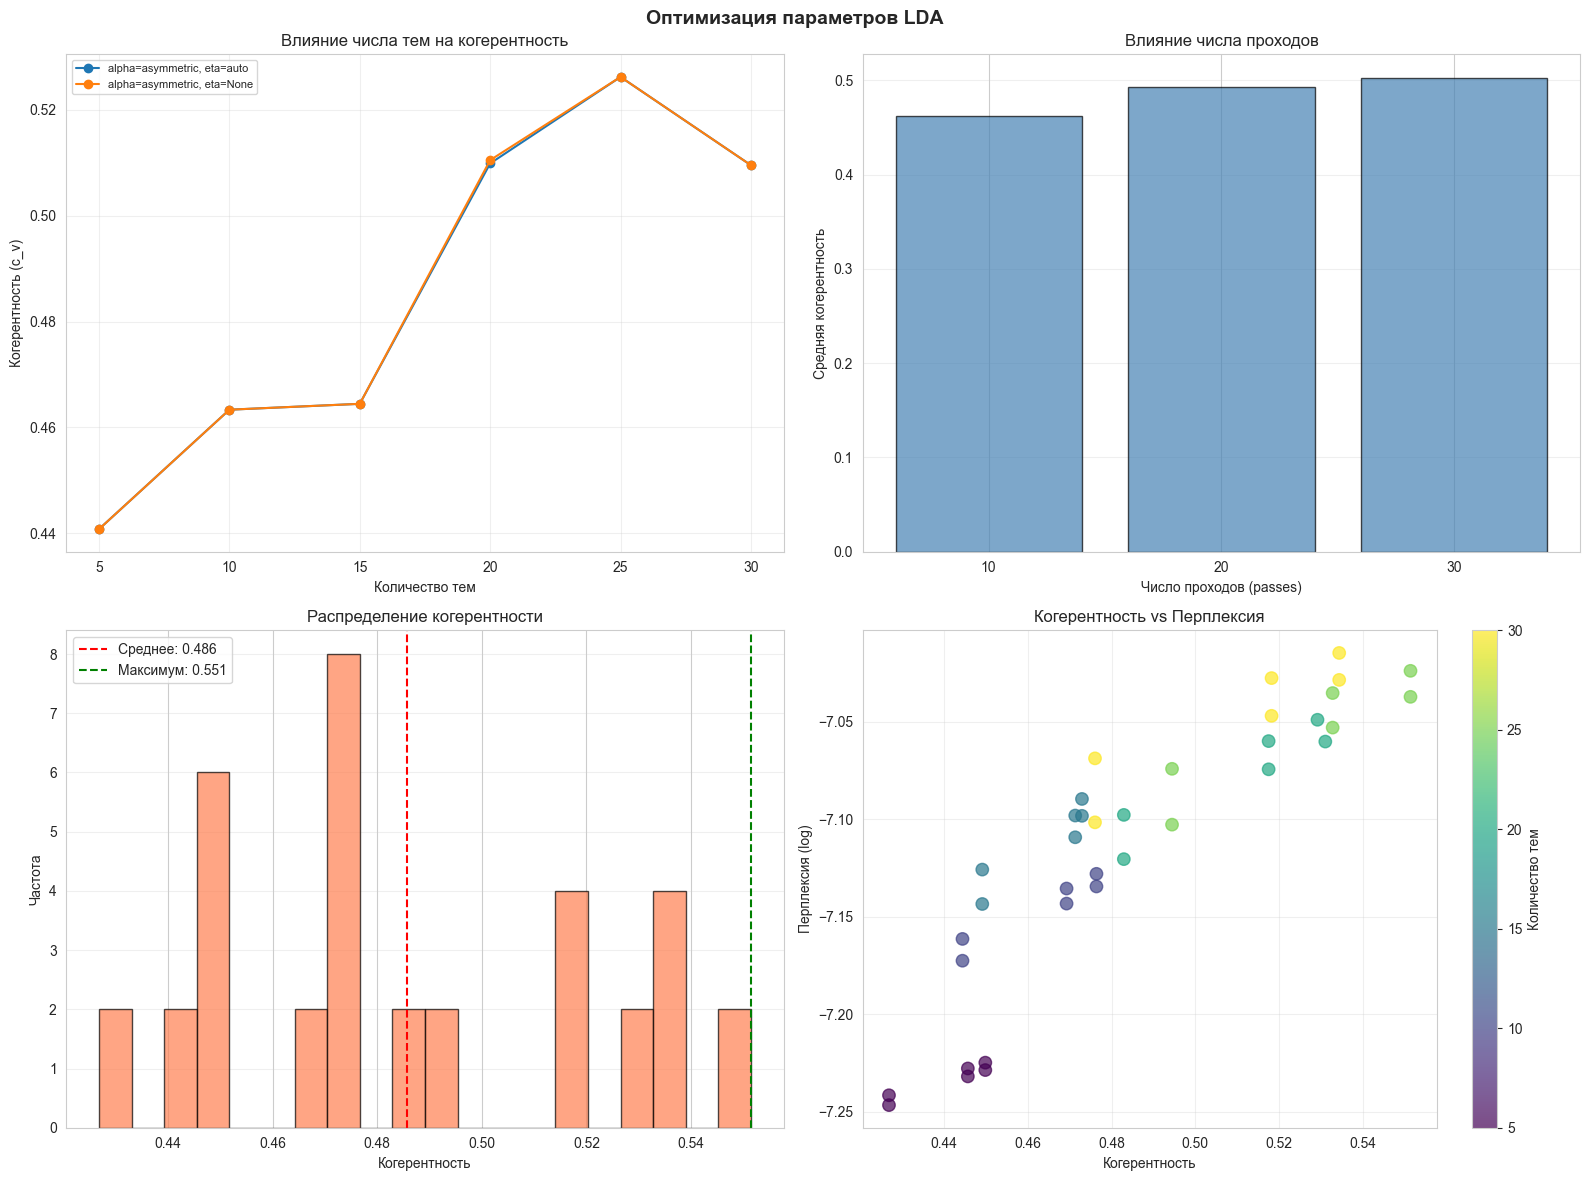

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\lda_optimization.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Влияние числа тем на когерентность (среднее по остальным параметрам)
ax = axes[0, 0]
for alpha in alpha_range:
    for eta in eta_range:
        eta_val = "None" if eta is None else eta
        subset = lda_results_df[
            (lda_results_df["alpha"] == alpha) &
            (lda_results_df["eta"]   == eta_val)
        ].groupby("num_topics")["coherence"].mean().reset_index()
        if not subset.empty:
            ax.plot(subset["num_topics"], subset["coherence"],
                    marker="o", label=f"alpha={alpha}, eta={eta_val}")
ax.set_xlabel("Количество тем")
ax.set_ylabel("Когерентность (c_v)")
ax.set_title("Влияние числа тем на когерентность")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Влияние числа passes
ax = axes[0, 1]
mean_by_passes = lda_results_df.groupby("passes")["coherence"].mean()
ax.bar(mean_by_passes.index.astype(str), mean_by_passes.values,
       color="steelblue", alpha=0.7, edgecolor="black")
ax.set_xlabel("Число проходов (passes)")
ax.set_ylabel("Средняя когерентность")
ax.set_title("Влияние числа проходов")
ax.grid(axis="y", alpha=0.3)

# Распределение когерентности
ax = axes[1, 0]
ax.hist(lda_results_df["coherence"], bins=20,
        color="coral", alpha=0.7, edgecolor="black")
ax.axvline(lda_results_df["coherence"].mean(), color="red",  linestyle="--",
           label=f'Среднее: {lda_results_df["coherence"].mean():.3f}')
ax.axvline(lda_results_df["coherence"].max(), color="green", linestyle="--",
           label=f'Максимум: {lda_results_df["coherence"].max():.3f}')
ax.set_xlabel("Когерентность")
ax.set_ylabel("Частота")
ax.set_title("Распределение когерентности")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Когерентность vs Перплексия
ax = axes[1, 1]
sc = ax.scatter(
    lda_results_df["coherence"], lda_results_df["perplexity"],
    c=lda_results_df["num_topics"], cmap="viridis", s=80, alpha=0.7
)
plt.colorbar(sc, ax=ax, label="Количество тем")
ax.set_xlabel("Когерентность")
ax.set_ylabel("Перплексия (log)")
ax.set_title("Когерентность vs Перплексия")
ax.grid(True, alpha=0.3)

plt.suptitle("Оптимизация параметров LDA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lda_optimization.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "lda_optimization.png")

## 4. Обучение финальной модели

In [7]:
best = lda_results_df.iloc[0]
print("Лучшая конфигурация:")
for k, v in best.items():
    print(f"  {k}: {v}")

final_lda = models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=int(best["num_topics"]),
    passes=int(best["passes"]),
    iterations=iterations,
    chunksize=chunksize,
    alpha=best["alpha"],
    eta=None if best["eta"] == "None" else best["eta"],
    workers=4,
    random_state=42,
)

final_lda.save(str(MODELS_DIR / "lda_model_best.model"))
print("\nМодель сохранена:", MODELS_DIR / "lda_model_best.model")

Лучшая конфигурация:
  num_topics: 25
  alpha: asymmetric
  eta: auto
  passes: 30
  coherence: 0.5514328112828
  perplexity: -7.0239806561003535

Модель сохранена: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\models\lda_model_best.model


## 5. Просмотр тем финальной модели

In [8]:
num_topics = final_lda.num_topics
print(f"Темы финальной LDA модели (num_topics={num_topics}):")
for idx, topic in final_lda.show_topics(
    num_topics=num_topics, num_words=10, formatted=False
):
    words = " + ".join(f"{w}({s:.3f})" for w, s in topic)
    print(f"  Тема {idx + 1}: {words}")

Темы финальной LDA модели (num_topics=25):
  Тема 1: движение(0.026) + система(0.018) + тело(0.018) + время(0.015) + скорость(0.013) + уравнение(0.012) + модель(0.011) + сила(0.010) + координата(0.010) + точка(0.009)
  Тема 2: наз(0.026) + пространство(0.021) + вектор(0.019) + число(0.016) + поле(0.015) + теория(0.014) + система(0.013) + нек(0.012) + пер(0.012) + матрица(0.011)
  Тема 3: число(0.027) + теория(0.022) + множество(0.017) + система(0.016) + наз(0.011) + понятие(0.010) + нек(0.010) + класс(0.008) + напр(0.008) + язык(0.008)
  Тема 4: управление(0.043) + множество(0.023) + система(0.023) + оптимальный(0.022) + функционал(0.014) + функция(0.014) + игра(0.010) + процесс(0.009) + свойство(0.009) + ограничение(0.009)
  Тема 5: деформация(0.025) + напряжение(0.023) + материал(0.022) + образец(0.013) + ползучесть(0.012) + рис(0.011) + состояние(0.010) + модель(0.010) + деформирование(0.009) + разрушение(0.008)
  Тема 6: группа(0.065) + алгебра(0.025) + кольцо(0.018) + модуль(0.014

## 6. Визуализация тем

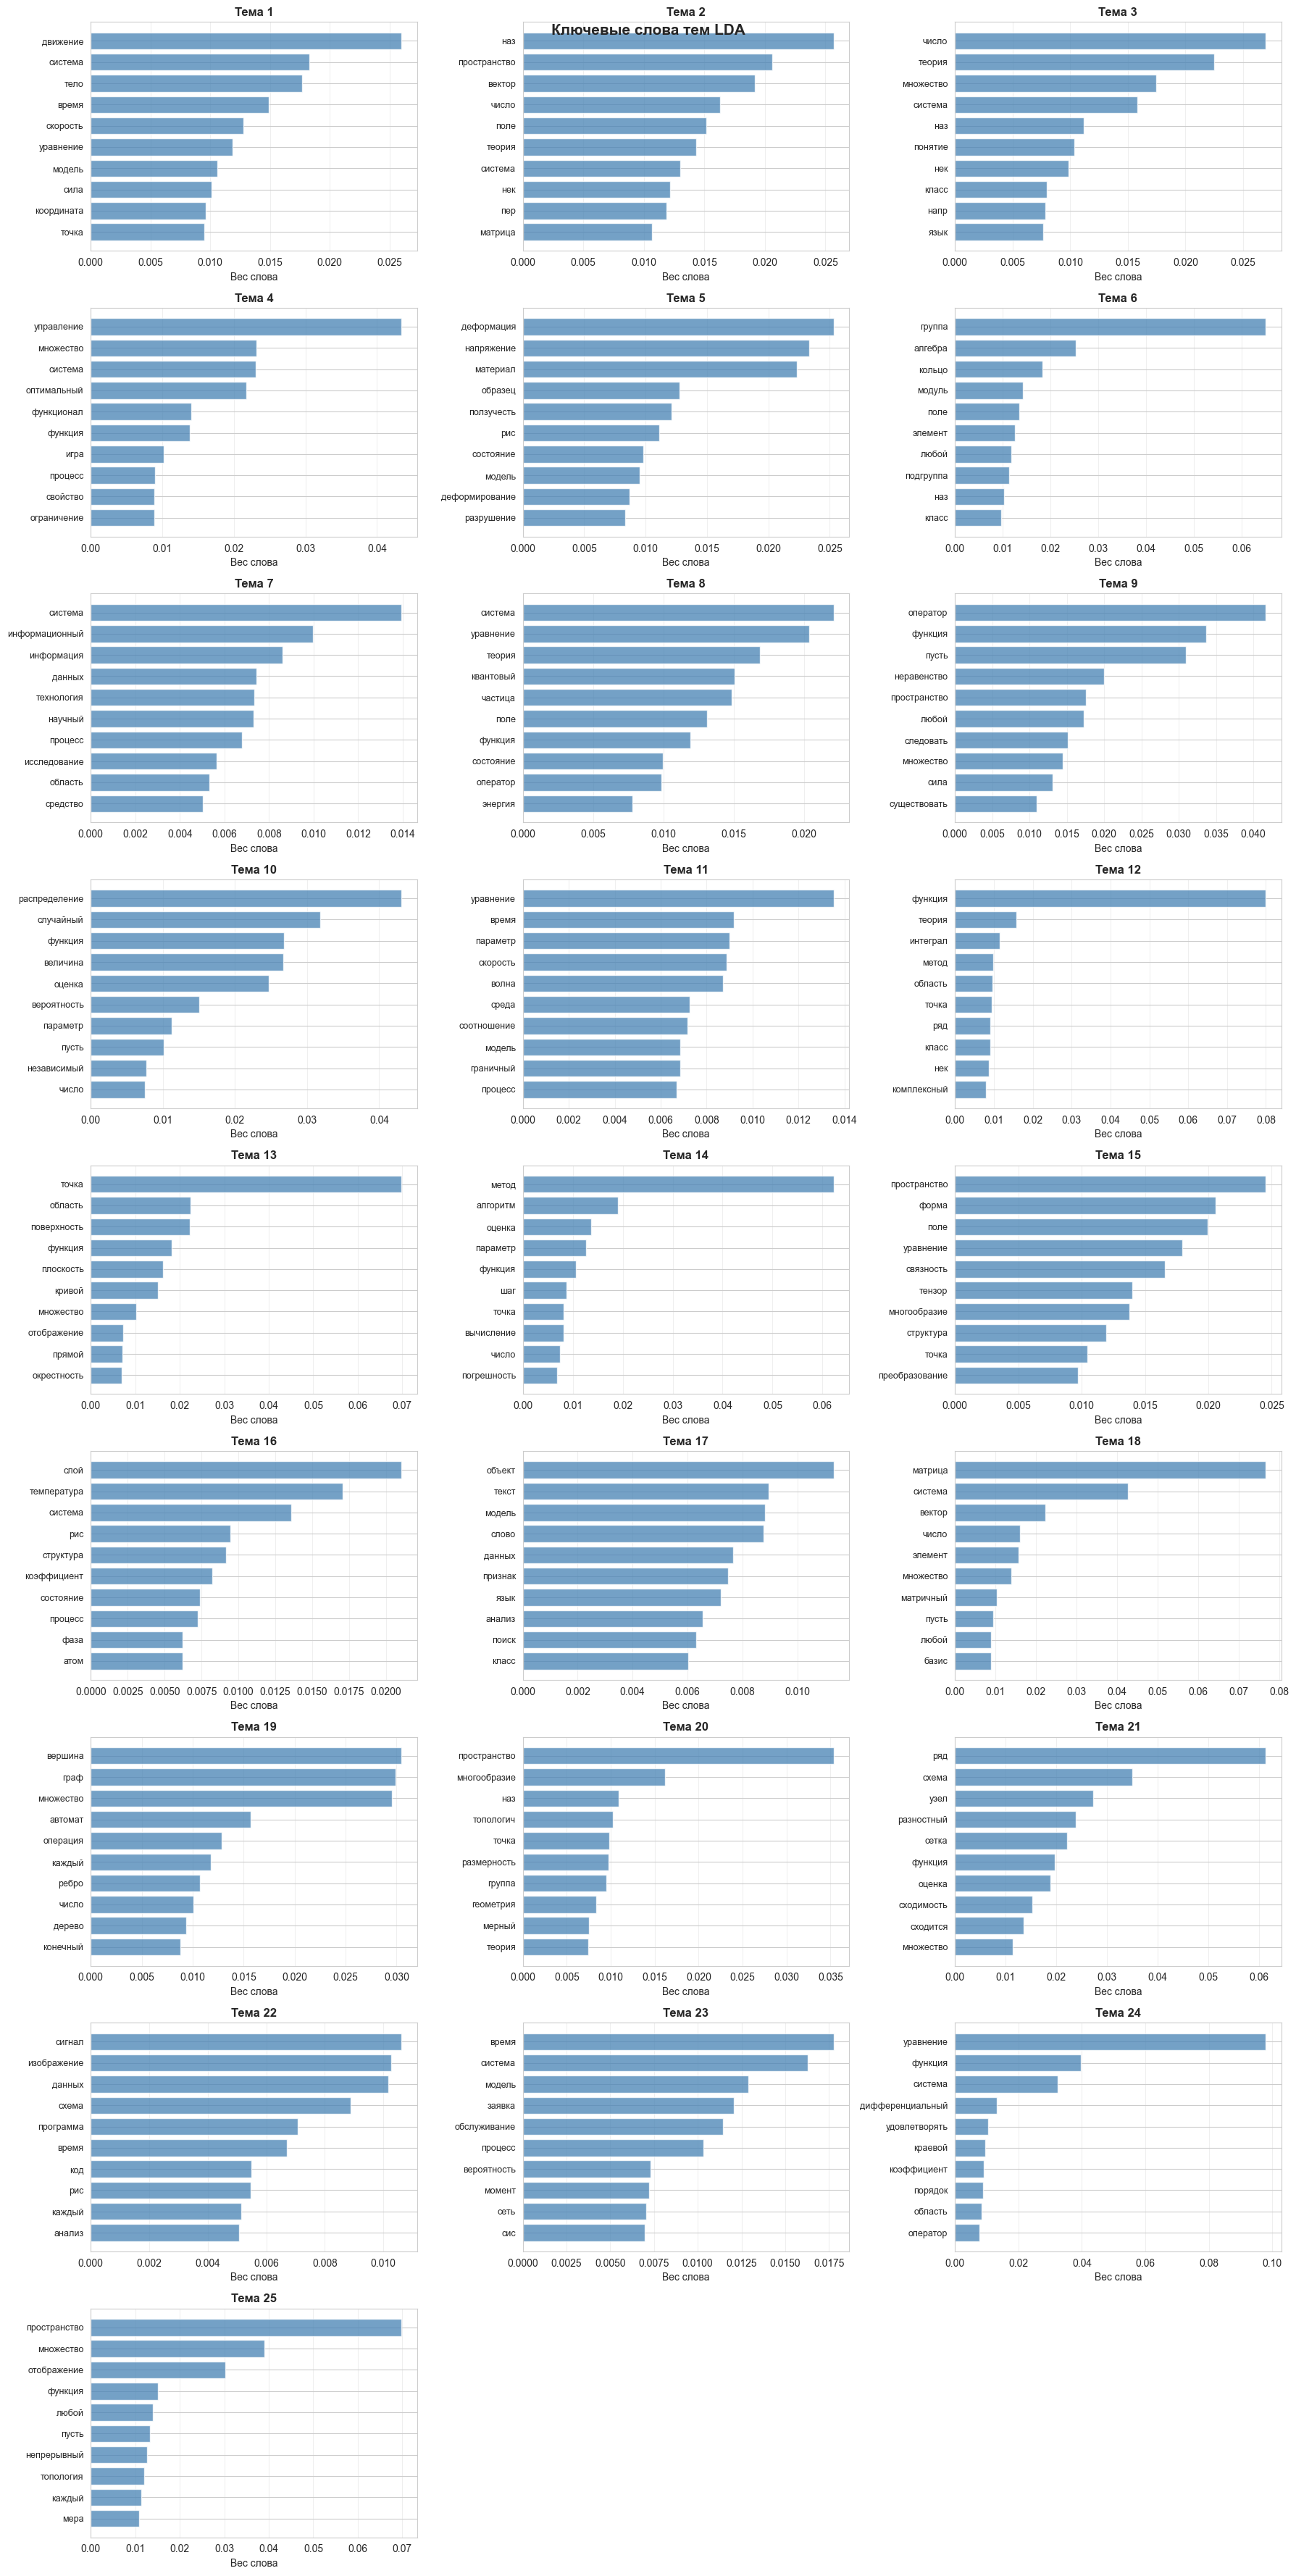

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\lda_topics.png


In [9]:
num_topics = final_lda.num_topics
cols = 3
rows = (num_topics + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for idx, topic in final_lda.show_topics(
    num_topics=num_topics, num_words=10, formatted=False
):
    words = [w for w, _ in topic]
    scores = [s for _, s in topic]
    ax = axes[idx]
    ax.barh(range(len(words)), scores, color="steelblue", alpha=0.75)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Вес слова")
    ax.set_title(f"Тема {idx + 1}", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

# Скрыть пустые подграфики
for j in range(num_topics, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Ключевые слова тем LDA", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lda_topics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "lda_topics.png")

## 7. Итоговые метрики качества

In [10]:
coherence_cv = CoherenceModel(
    model=final_lda, texts=texts, dictionary=dictionary, coherence="c_v"
).get_coherence()

coherence_umass = CoherenceModel(
    model=final_lda, texts=texts, dictionary=dictionary, coherence="u_mass"
).get_coherence()

perplexity = final_lda.log_perplexity(corpus)

print("Метрики финальной LDA модели")
print(f"  Когерентность c_v:    {coherence_cv:.4f}")
print(f"  Когерентность u_mass: {coherence_umass:.4f}")
print(f"  Перплексия (log):     {perplexity:.4f}")
print(f"  Число тем:            {final_lda.num_topics}")

pd.DataFrame([{
    "model": "LDA",
    "num_topics": final_lda.num_topics,
    "coherence_cv": coherence_cv,
    "coherence_umass": coherence_umass,
    "perplexity": perplexity,
}]).to_csv(OUTPUT_DIR / "lda_final_metrics.csv", index=False)
print("Метрики сохранены:", OUTPUT_DIR / "lda_final_metrics.csv")

Метрики финальной LDA модели
  Когерентность c_v:    0.5514
  Когерентность u_mass: -1.1911
  Перплексия (log):     -7.0240
  Число тем:            25
Метрики сохранены: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\lda_final_metrics.csv
